# numpy-nn

A neural network framework built from scratch with NumPy — featuring backpropagation, residual connections, and autoencoders, all demonstrated on handwritten digit data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from nn import Linear, ReLU, Sigmoid, Sequential, SkipBlock, Autoencoder, build_mlp
from losses import CrossEntropyLoss, MSELoss
from optimizers import Adam
from trainer import Trainer, accuracy

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

digits = load_digits()
X = digits.data / 16.0
Y = digits.target[:, None]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(Y))} classes")
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Dataset: 1797 samples, 64 features, 10 classes
Train: 1437  |  Test: 360


## MLP Classification

Building a multi-layer perceptron to classify handwritten digits (8x8 pixel images, 10 classes). The network uses ReLU activations and is trained with Adam + cross-entropy loss.

In [2]:
rng = np.random.default_rng(42)
mlp = build_mlp([64, 128, 64, 10], activation_cls=ReLU, rng=rng)

optimizer = Adam(mlp.parameters(), lr=1e-3)
trainer = Trainer(mlp, optimizer, CrossEntropyLoss(), metric_fn=accuracy,
                  epochs=50, batch_size=32, seed=42)
trainer.fit(X_train, Y_train, X_val=X_test, Y_val=Y_test)

print(f"Final train accuracy: {trainer.history['train_metric'][-1]:.3f}")
print(f"Final test accuracy:  {trainer.history['val_metric'][-1]:.3f}")

Final train accuracy: 1.000
Final test accuracy:  0.981


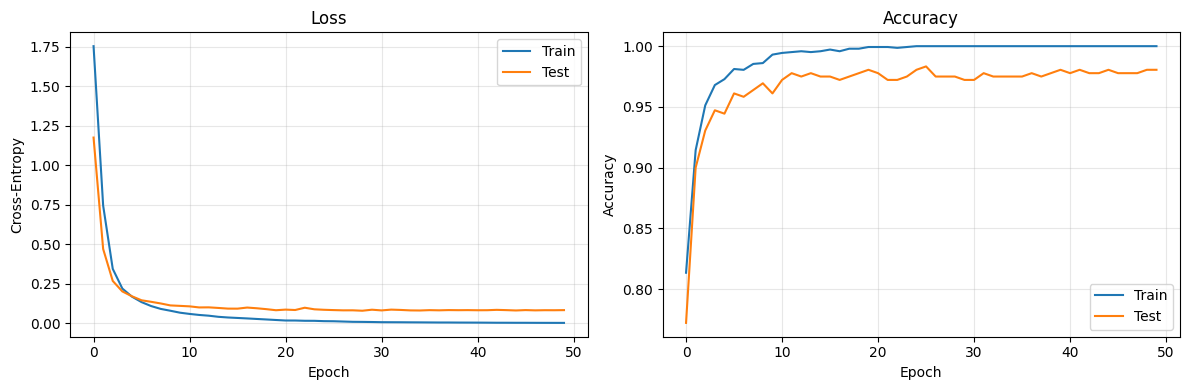

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(trainer.history["train_loss"], label="Train")
axes[0].plot(trainer.history["val_loss"], label="Test")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-Entropy")
axes[0].legend()

axes[1].plot(trainer.history["train_metric"], label="Train")
axes[1].plot(trainer.history["val_metric"], label="Test")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Deeper Networks with Skip Connections

Skip (residual) connections add the layer's input directly to its output, giving gradients a shortcut through the network. This stabilizes training in deeper architectures where vanilla MLPs can struggle with vanishing gradients.

In [4]:
rng1 = np.random.default_rng(42)
deep_mlp = build_mlp([64, 64, 64, 64, 64, 10], activation_cls=ReLU, rng=rng1)

rng2 = np.random.default_rng(42)
skip_mlp = Sequential(
    Linear(64, 64, rng2), ReLU(),
    SkipBlock(64, ReLU, rng2), ReLU(),
    SkipBlock(64, ReLU, rng2), ReLU(),
    SkipBlock(64, ReLU, rng2), ReLU(),
    Linear(64, 10, rng2),
)

results = {}
for name, model in [("Deep MLP", deep_mlp), ("Deep MLP + Skip", skip_mlp)]:
    opt = Adam(model.parameters(), lr=1e-3)
    t = Trainer(model, opt, CrossEntropyLoss(), metric_fn=accuracy,
                epochs=50, batch_size=32, seed=42)
    t.fit(X_train, Y_train, X_val=X_test, Y_val=Y_test)
    results[name] = t
    print(f"{name:20s}  Test Acc: {t.history['val_metric'][-1]:.3f}")

Deep MLP              Test Acc: 0.978
Deep MLP + Skip       Test Acc: 0.972


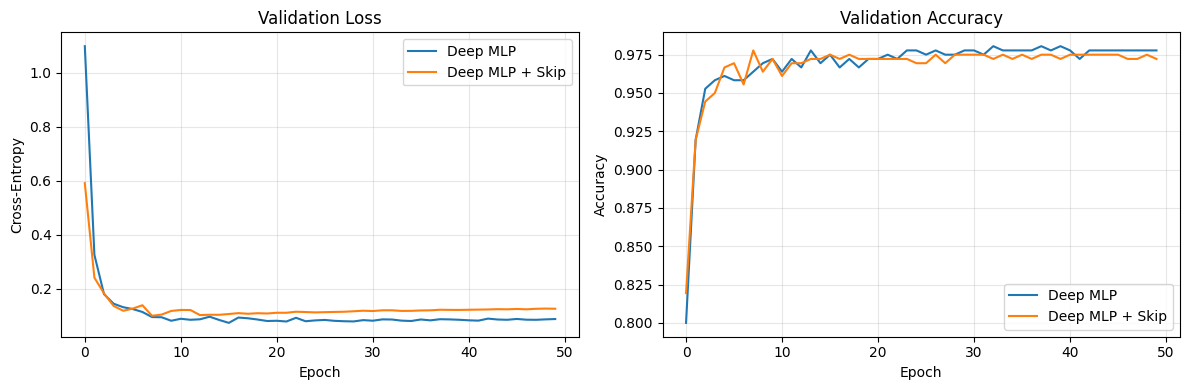

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, t in results.items():
    axes[0].plot(t.history["val_loss"], label=name)
    axes[1].plot(t.history["val_metric"], label=name)

axes[0].set(title="Validation Loss", xlabel="Epoch", ylabel="Cross-Entropy")
axes[0].legend()
axes[1].set(title="Validation Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Autoencoder: Compressing and Reconstructing Digits

An autoencoder learns to compress inputs through a bottleneck and reconstruct them. Here we squeeze 64-dimensional digit images down to just 16 dimensions and reconstruct them using MSE loss.

In [6]:
rng = np.random.default_rng(42)
encoder = build_mlp([64, 32, 16], activation_cls=ReLU, rng=rng)
decoder = build_mlp([16, 32, 64], activation_cls=ReLU, rng=rng)
autoencoder = Autoencoder(encoder, decoder)

opt = Adam(autoencoder.parameters(), lr=1e-3)
ae_trainer = Trainer(autoencoder, opt, MSELoss(), epochs=100, batch_size=32, seed=42)
ae_trainer.fit(X_train, X_train, X_val=X_test, Y_val=X_test)

print(f"Final reconstruction MSE: {ae_trainer.history['val_loss'][-1]:.4f}")

Final reconstruction MSE: 0.0078


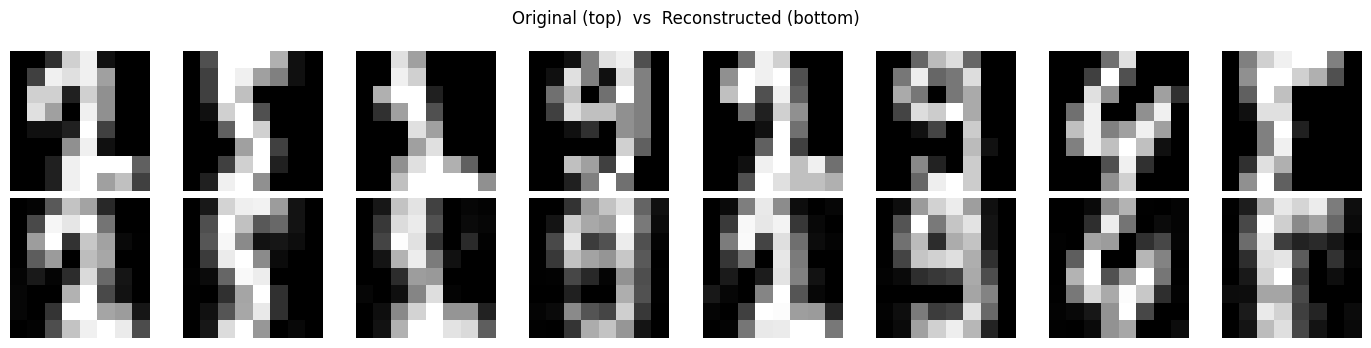

In [7]:
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
sample_idx = np.random.default_rng(0).choice(len(X_test), 8, replace=False)
reconstructions = autoencoder.forward(X_test[sample_idx])

for i in range(8):
    axes[0, i].imshow(X_test[sample_idx[i]].reshape(8, 8), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(reconstructions[i].reshape(8, 8), 0, 1), cmap="gray")
    axes[1, i].axis("off")

fig.suptitle("Original (top)  vs  Reconstructed (bottom)", fontsize=12)
plt.tight_layout()
plt.show()

## Takeaways

- **Backpropagation works by composing local gradients.** Each layer computes its own gradient during the backward pass and passes the upstream gradient to the previous layer. This modular design is exactly how PyTorch and TensorFlow work under the hood.
- **Skip connections stabilize deep network training.** By providing a direct path for gradients, residual blocks mitigate the vanishing gradient problem and help deeper architectures converge.
- **Autoencoders learn compact representations.** Forcing data through a bottleneck teaches the network to preserve only the most important features — a form of unsupervised dimensionality reduction.

Every layer, loss function, and optimizer in this project is implemented from scratch with NumPy.